# Gross vs Net Performance Analysis

**Docker image**: `ml4t`

This notebook provides a comprehensive framework for analyzing the gap between gross
(theoretical) and net (realized) strategy performance. This is the ultimate reality check
for any trading strategy.

**Key Learning Objectives:**
- Understand the full cost stack from gross to net
- Apply realistic costs to strategy backtests
- Compute net Sharpe under a parameterised cost stack
- Compare three archetypes driven by real ETF return series under a common cost stack

**Book Reference:** Chapter 18: Section 18.8 (Practical Guardrails: When Costs Kill a Strategy)

**Prerequisites:** Read [`01_cost_taxonomy`](01_cost_taxonomy.ipynb) for the cost stack and
[`09_frequency_tradeoff`](09_frequency_tradeoff.ipynb) for turnover-driven breakeven logic.

## 1. Setup

In [1]:
"""Gross vs Net Performance - Full cost stack arithmetic and capacity analysis."""

import warnings
from dataclasses import dataclass

warnings.filterwarnings("ignore")

import numpy as np
import plotly.graph_objects as go
import polars as pl
from ml4t.diagnostic.visualization.backtest import (
    plot_cost_over_time,
    plot_cost_sensitivity,
    plot_cost_waterfall,
)
from plotly.subplots import make_subplots

from data import load_etfs
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds

OUTPUT_DIR = get_output_dir(18, "cost_attribution")

In [2]:
# No heavy computation — runs in seconds. Retained for Papermill compatibility.
SEED = 42
# The three archetypes are driven by real daily ETF return series; only the
# turnover/leverage/short configuration differs between them.
GROSS_START_DATE = "2021-01-01"
GROSS_END_DATE = "2023-12-31"

In [3]:
set_global_seeds(SEED)

## 2. The Cost Stack

Converting gross to net involves multiple layers:

```
Gross Strategy Return
    - Bid-Ask Spread Costs
    - Market Impact Costs
    = Trading P&L
    - Commission/Fees
    - Financing Costs (margin interest, borrow costs)
    = Net Trading P&L
    - Fund Expenses (mgmt fee, admin)
    = Investor Net Return
```

### CostStack dataclass: fields

The dataclass groups trading, financing, and fund-expense parameters so a
single instance carries the full set of frictions used throughout the
notebook.

In [4]:
@dataclass
class CostStack:
    """Complete cost stack for gross-to-net conversion."""

    # Trading costs (bps per one-way trade)
    spread_cost_bps: float = 2.0
    impact_cost_bps: float = 5.0  # Varies with trade size

    # Transaction costs
    commission_bps: float = 1.0
    exchange_fee_bps: float = 0.5

    # Financing costs (annualized)
    margin_rate_annual: float = 0.05  # 5% margin interest
    borrow_rate_annual: float = 0.01  # 1% for shorts

    # Fund expenses (annualized)
    management_fee_annual: float = 0.02  # 2%
    admin_fee_annual: float = 0.002  # 20 bps

    def trading_cost_per_trade(self, trade_size_pct: float = 0.1) -> float:
        """Total trading cost per one-way trade in bps.

        Impact scales relative to a baseline trade size of 0.1 of ADV
        (`trade_size_pct=0.1`) using a square-root law. Doubling
        `trade_size_pct` raises the impact term by `sqrt(2)`; halving it
        cuts the impact term by `sqrt(2)`.
        """
        scaled_impact = self.impact_cost_bps * np.sqrt(trade_size_pct / 0.1)
        return self.spread_cost_bps + scaled_impact

    def annual_trading_cost(self, annual_turnover: float) -> float:
        """Annual trading cost in decimal."""
        # Turnover is one-way, costs apply to both legs
        cost_bps = self.trading_cost_per_trade()
        commission_bps = self.commission_bps + self.exchange_fee_bps
        total_bps = cost_bps + commission_bps
        return annual_turnover * 2 * (total_bps / 10000)

    def annual_financing_cost(
        self,
        gross_leverage: float = 1.0,
        short_pct: float = 0.0,
    ) -> float:
        """Annual financing cost in decimal."""
        # Margin interest on leverage
        margin_cost = max(0, gross_leverage - 1) * self.margin_rate_annual
        # Borrow cost on shorts
        borrow_cost = short_pct * self.borrow_rate_annual
        return margin_cost + borrow_cost

    def annual_expense_cost(self) -> float:
        """Annual fund expenses in decimal."""
        return self.management_fee_annual + self.admin_fee_annual

### Default cost stack instance

In [5]:
# Default cost stack
costs = CostStack()

print("Cost Stack Summary:")
print(f"  Trading cost (per trade): {costs.trading_cost_per_trade():.1f} bps")
print(f"  Commission + fees: {costs.commission_bps + costs.exchange_fee_bps:.1f} bps")
print(f"  Margin interest: {costs.margin_rate_annual:.1%} p.a.")
print(f"  Short borrow cost: {costs.borrow_rate_annual:.1%} p.a.")
print(f"  Management fee: {costs.management_fee_annual:.1%} p.a.")

Cost Stack Summary:
  Trading cost (per trade): 7.0 bps
  Commission + fees: 1.5 bps
  Margin interest: 5.0% p.a.
  Short borrow cost: 1.0% p.a.
  Management fee: 2.0% p.a.


## 3. Real Return Series and Strategy Configurations

**Scope**: this section drives three strategy *configurations* — a high-turnover
momentum profile, a leveraged long-short profile, and a low-turnover profile —
from **real daily ETF return series**, then varies turnover and leverage while
holding the cost stack fixed to read off how the stack transforms gross into net.
The gross return series are real (QQQ for momentum, a dollar-neutral QQQ−IWM
spread for long-short, SPY for the low-turnover profile); the turnover and
leverage are configuration choices, not return-generating assumptions. For a
full real-data ETF momentum backtest, see `case_studies/etfs/14_backtest.py`.

### Load Real ETF Return Series

In [6]:
_panel = load_etfs(
    symbols=["SPY", "QQQ", "IWM"], start_date=GROSS_START_DATE, end_date=GROSS_END_DATE
)
_wide = (
    _panel.sort("symbol", "timestamp")
    .with_columns(r=pl.col("close").pct_change().over("symbol"))
    .pivot(values="r", index="timestamp", on="symbol")
    .sort("timestamp")
    .drop_nulls()
)
spy_ret = _wide["SPY"].to_numpy()
qqq_ret = _wide["QQQ"].to_numpy()
iwm_ret = _wide["IWM"].to_numpy()
ls_ret = qqq_ret - iwm_ret  # dollar-neutral long QQQ / short IWM spread
print(
    f"Loaded {_wide.height} daily returns ({GROSS_START_DATE}..{GROSS_END_DATE}) for SPY, QQQ, IWM"
)

Loaded 752 daily returns (2021-01-01..2023-12-31) for SPY, QQQ, IWM


### Strategy Builder

Wraps a real gross-return series with a turnover/leverage/short configuration.
Turnover is the per-day one-way turnover implied by the annual figure.

In [7]:
def build_strategy(
    gross_returns: np.ndarray,
    annual_turnover: float,
    gross_leverage: float = 1.0,
    short_pct: float = 0.0,
    name: str = "Strategy",
) -> dict:
    """Pair a real return series with a turnover/leverage configuration."""
    daily_turnover = annual_turnover / 252
    return {
        "name": name,
        "gross_returns": gross_returns,
        "turnover": np.full(len(gross_returns), daily_turnover),
        "annual_turnover": annual_turnover,
        "gross_leverage": gross_leverage,
        "short_pct": short_pct,
    }

In [8]:
# Three configurations spanning turnover and leverage extremes, each on a real series.

# High-turnover momentum: QQQ, long-only, no leverage, 24x annual turnover.
hf_momentum = build_strategy(
    qqq_ret,
    annual_turnover=24.0,  # 2400% annual
    gross_leverage=1.0,
    short_pct=0.0,
    name="High Turnover (24x, Long-Only)",
)

# Leveraged long-short: QQQ-IWM spread, 200% gross, 50% short, 6x annual turnover.
long_short = build_strategy(
    ls_ret,
    annual_turnover=6.0,  # 600% annual
    gross_leverage=2.0,  # 200% gross
    short_pct=0.5,
    name="Leveraged Long-Short (6x, 2x Gross)",
)

# Low-turnover: SPY, long-only, no leverage, 1x annual turnover.
value_strategy = build_strategy(
    spy_ret,
    annual_turnover=1.0,  # 100% annual
    gross_leverage=1.0,
    short_pct=0.0,
    name="Low Turnover (1x, Long-Only)",
)

strategies = [hf_momentum, long_short, value_strategy]

## 4. Apply Costs and Compute Net Returns

In [9]:
def apply_cost_stack(
    strategy: dict,
    costs: CostStack,
) -> dict:
    """Apply full cost stack to get net returns."""
    gross_returns = strategy["gross_returns"]
    turnover = strategy["turnover"]

    # Daily trading costs
    trading_cost_bps = costs.trading_cost_per_trade()
    commission_bps = costs.commission_bps + costs.exchange_fee_bps
    daily_trading_cost = turnover * 2 * ((trading_cost_bps + commission_bps) / 10000)

    # Daily financing costs
    financing_annual = costs.annual_financing_cost(
        strategy["gross_leverage"], strategy["short_pct"]
    )
    daily_financing = financing_annual / 252

    # Daily fund expenses
    expense_annual = costs.annual_expense_cost()
    daily_expense = expense_annual / 252

    # Net returns
    net_returns = gross_returns - daily_trading_cost - daily_financing - daily_expense

    return {
        **strategy,
        "net_returns": net_returns,
        "trading_cost": daily_trading_cost,
        "financing_cost": np.full_like(gross_returns, daily_financing),
        "expense_cost": np.full_like(gross_returns, daily_expense),
    }


# Apply costs
for i, strat in enumerate(strategies):
    strategies[i] = apply_cost_stack(strat, costs)

## 5. Performance Comparison

In [10]:
def compute_performance(returns: np.ndarray) -> dict:
    """Compute performance metrics."""
    ann_return = np.mean(returns) * 252
    ann_vol = np.std(returns) * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else 0

    cumulative = np.cumprod(1 + returns)
    rolling_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - rolling_max) / rolling_max
    max_dd = drawdown.min()

    return {
        "Annual Return": ann_return,
        "Annual Vol": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd,
    }

In [11]:
# Summary table
print("\nGross vs Net Performance Comparison:")
comparison_rows = []
for strat in strategies:
    gross_perf = compute_performance(strat["gross_returns"])
    net_perf = compute_performance(strat["net_returns"])
    drag = gross_perf["Annual Return"] - net_perf["Annual Return"]
    comparison_rows.append(
        {
            "Configuration": strat["name"],
            "Turnover (x)": strat["annual_turnover"],
            "Gross SR": round(gross_perf["Sharpe Ratio"], 2),
            "Net SR": round(net_perf["Sharpe Ratio"], 2),
            "Cost Drag (%)": round(drag * 100, 1),
        }
    )
pl.DataFrame(comparison_rows)


Gross vs Net Performance Comparison:


Configuration,Turnover (x),Gross SR,Net SR,Cost Drag (%)
str,f64,f64,f64,f64
"""High Turnover (24x, Long-Only)""",24.0,0.54,0.28,6.3
"""Leveraged Long-Short (6x, 2x G…",6.0,0.47,-0.07,8.7
"""Low Turnover (1x, Long-Only)""",1.0,0.66,0.52,2.4


**Mechanism**: the gross-to-net gap widens with turnover at this commission
level. The high-turnover momentum configuration (QQQ, 24x) sheds 0.26 of Sharpe
to costs (0.54 → 0.28), while the low-turnover configuration (SPY, 1x) loses
only 0.14 (0.66 → 0.52), because each round trip incurs the same per-trade bps
cost and high turnover pays it far more often. The leveraged long-short turns
negative once financing stacks on top of turnover.

## 6. Equity Curve Comparison

### Build cumulative equity series

In [12]:
equity_series = [
    {
        "name": strat["name"],
        "cum_gross": np.cumprod(1 + strat["gross_returns"]),
        "cum_net": np.cumprod(1 + strat["net_returns"]),
    }
    for strat in strategies
]

### Stacked subplot of gross vs net equity curves

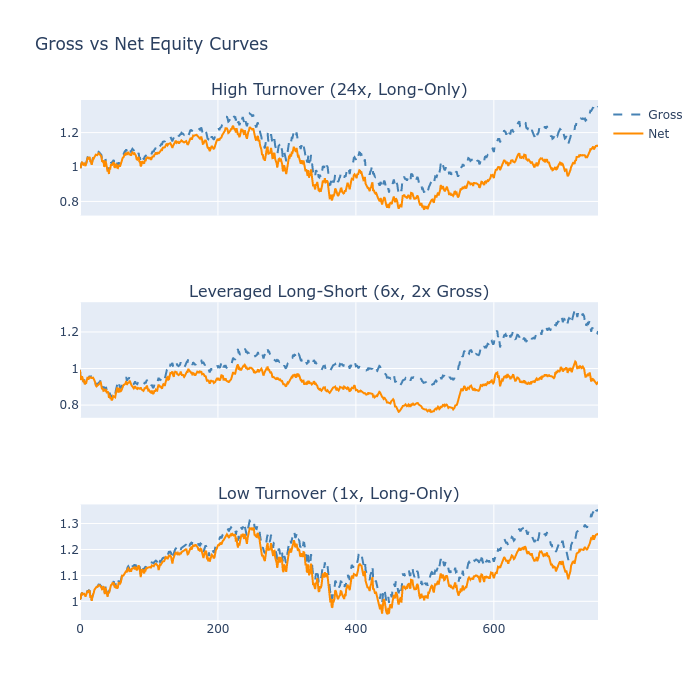

In [13]:
fig = make_subplots(
    rows=len(strategies),
    cols=1,
    subplot_titles=[s["name"] for s in equity_series],
    shared_xaxes=True,
)

for i, eq in enumerate(equity_series):
    fig.add_trace(
        go.Scatter(
            y=eq["cum_gross"],
            mode="lines",
            name="Gross",
            line=dict(color="steelblue", dash="dash"),
            showlegend=(i == 0),
        ),
        row=i + 1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            y=eq["cum_net"],
            mode="lines",
            name="Net",
            line=dict(color="darkorange"),
            showlegend=(i == 0),
        ),
        row=i + 1,
        col=1,
    )

fig.update_layout(
    title="Gross vs Net Equity Curves",
    height=200 * len(equity_series) + 100,
)
fig.show()

**Interpretation**: The equity curves make cost drag path-dependent rather than
abstract. Small daily deductions compound into visibly different wealth paths,
especially for the highest-turnover strategy.

## 7. Cost Attribution

In [14]:
# Cost breakdown for each strategy
cost_breakdown = []

for strat in strategies:
    # Annual costs
    trading_annual = np.mean(strat["trading_cost"]) * 252
    financing_annual = np.mean(strat["financing_cost"]) * 252
    expense_annual = np.mean(strat["expense_cost"]) * 252
    total_annual = trading_annual + financing_annual + expense_annual

    cost_breakdown.append(
        {
            "Strategy": strat["name"],
            "Trading Costs": trading_annual,
            "Financing Costs": financing_annual,
            "Fund Expenses": expense_annual,
            "Total Costs": total_annual,
        }
    )

cost_df = pl.DataFrame(cost_breakdown)
print("\nAnnual Cost Attribution:")
cost_df


Annual Cost Attribution:


Strategy,Trading Costs,Financing Costs,Fund Expenses,Total Costs
str,f64,f64,f64,f64
"""High Turnover (24x, Long-Only)""",0.0408,0.0,0.022,0.0628
"""Leveraged Long-Short (6x, 2x G…",0.0102,0.055,0.022,0.0872
"""Low Turnover (1x, Long-Only)""",0.0017,0.0,0.022,0.0237


**Finding**: The attribution table separates execution drag from financing drag.
That distinction matters because lowering turnover will not fix a strategy whose
economics are dominated by leverage and borrow costs.

In [15]:
# === SAVE COST ATTRIBUTION FOR DOWNSTREAM CHAPTERS ===
# Ch20 (Synthesis) consumes this for cost impact analysis
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cost_df.write_parquet(OUTPUT_DIR / "cost_attribution.parquet")
print(f"\nSaved: {OUTPUT_DIR / 'cost_attribution.parquet'}")

reference_strategy = strategies[0]
gross_series = pl.Series("gross", reference_strategy["gross_returns"])
net_series = pl.Series("net", reference_strategy["net_returns"])
gross_total = float(np.prod(1 + reference_strategy["gross_returns"]) - 1)
net_total = float(np.prod(1 + reference_strategy["net_returns"]) - 1)
trading_drag = float(np.sum(reference_strategy["trading_cost"]))

cost_waterfall = plot_cost_waterfall(
    gross_pnl=gross_total,
    commission=trading_drag,
    slippage=0.0,
    net_pnl=net_total,
    title=f"{reference_strategy['name']} Cost Waterfall",
)
cost_waterfall.write_html(str(OUTPUT_DIR / "diagnostic_cost_waterfall.html"))

cost_sensitivity = plot_cost_sensitivity(
    returns=gross_series,
    base_costs_bps=costs.trading_cost_per_trade() + costs.commission_bps + costs.exchange_fee_bps,
    trades_per_year=252,
    title=f"{reference_strategy['name']} Cost Sensitivity",
)
cost_sensitivity.write_html(str(OUTPUT_DIR / "diagnostic_cost_sensitivity.html"))

cost_over_time = plot_cost_over_time(
    dates=np.arange(len(reference_strategy["gross_returns"])),
    gross_returns=gross_series,
    net_returns=net_series,
    rolling_window=63,
    title=f"{reference_strategy['name']} Cost Impact Over Time",
)
cost_over_time.write_html(str(OUTPUT_DIR / "diagnostic_cost_over_time.html"))


Saved: 18_transaction_costs/output/cost_attribution/cost_attribution.parquet


**Interpretation**: Persisting these diagnostics matters because later chapters need
cost attribution as reusable data, not just as an illustration. The saved artifacts
turn this notebook into a shared input for downstream synthesis.

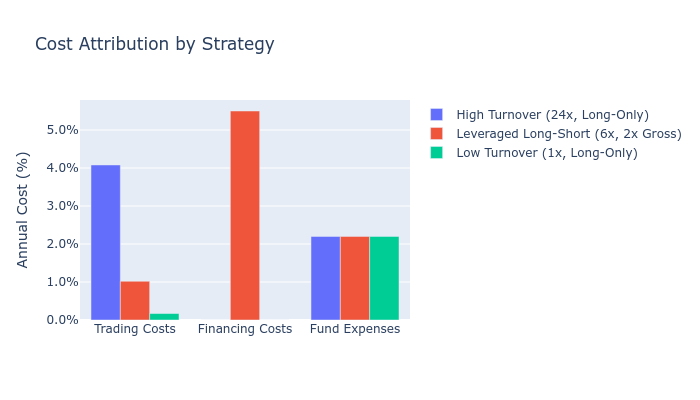

In [16]:
# Grouped bar chart
fig = go.Figure()
categories = ["Trading Costs", "Financing Costs", "Fund Expenses"]
colors = ["steelblue", "darkorange", "forestgreen"]

for i, strat in enumerate(cost_breakdown):
    fig.add_trace(
        go.Bar(
            name=strat["Strategy"],
            x=categories,
            y=[strat[c] for c in categories],
        )
    )

fig.update_layout(
    title="Cost Attribution by Strategy",
    yaxis_title="Annual Cost (%)",
    yaxis_tickformat=".1%",
    barmode="group",
    height=400,
)
fig.show()

**Finding**: The grouped bars show that "cost" is not a single knob. Different
strategy archetypes fail for different reasons, so the repair has to target the
dominant source of drag rather than treat all frictions as interchangeable.

## 8. Sensitivity Analysis: Costs vs Turnover

In [17]:
# How does net Sharpe vary with turnover for different one-way cost levels?
turnovers = np.linspace(0.5, 30, 50)
one_way_cost_bps = [5, 10, 20, 40]  # one-way trading cost in bps

sensitivity_data = []

for cost_bps in one_way_cost_bps:
    for turnover in turnovers:
        # Gross Sharpe of 1.5, 15% vol
        gross_daily_ret = 1.5 * 0.15 / 252
        # Annual turnover is already one-way; cost_bps is one-way.
        daily_cost = turnover / 252 * (cost_bps / 10000)
        net_daily_ret = gross_daily_ret - daily_cost
        net_sharpe = net_daily_ret * 252 / 0.15

        sensitivity_data.append(
            {
                "Turnover": turnover,
                "One-Way Cost (bps)": cost_bps,
                "Net Sharpe": net_sharpe,
            }
        )

sens_df = pl.DataFrame(sensitivity_data)

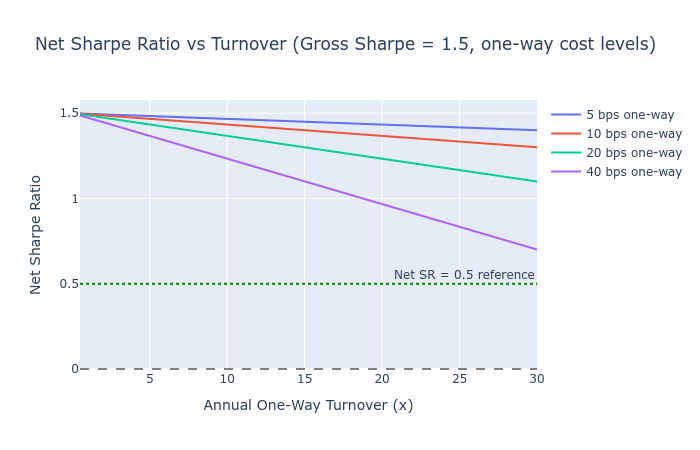

In [18]:
fig = go.Figure()

for cost_bps in one_way_cost_bps:
    subset = sens_df.filter(pl.col("One-Way Cost (bps)") == cost_bps)
    fig.add_trace(
        go.Scatter(
            x=subset["Turnover"].to_list(),
            y=subset["Net Sharpe"].to_list(),
            mode="lines",
            name=f"{cost_bps} bps one-way",
        )
    )

fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.add_hline(y=0.5, line_dash="dot", line_color="green", annotation_text="Net SR = 0.5 reference")

fig.update_layout(
    title="Net Sharpe Ratio vs Turnover (Gross Sharpe = 1.5, one-way cost levels)",
    xaxis_title="Annual One-Way Turnover (x)",
    yaxis_title="Net Sharpe Ratio",
    height=450,
)
fig.show()

**Interpretation**: The sensitivity chart is the general policy rule behind the
case studies. Each line plots Net Sharpe as a function of annual one-way
turnover at a fixed one-way cost level. As per-trade one-way costs rise, the
feasible turnover range contracts sharply even if the gross signal quality
stays unchanged.

## 9. Frobenius-Norm Turnover Diagnostic

Standard turnover measures weight changes: $\sum_i |w_{i,t} - w_{i,t-1}|$.
But this conflates **signal-driven turnover** (intentional) with **null turnover**
(caused by price drift, corporate actions, rebalancing to equal weight).

The **Frobenius-norm turnover** decomposes total weight change into:

$$\|\Delta W\|_F = \|W_t - W_{t-1}\|_F \approx \underbrace{\|\Delta W^{\text{signal}}\|_F}_{\text{intentional}} + \underbrace{\|\Delta W^{\text{null}}\|_F}_{\text{mechanical}}$$

Measuring null turnover tells you how much cost you pay just to maintain a
portfolio — before any signal even acts.

### Set up the constant-signal covariance scenario

20 assets, base covariance held fixed, only a small rotation of the first two
axes each period to simulate regime drift. Signal weights are the
minimum-variance solution — so any turnover is null turnover.

In [19]:
n_assets = 20
n_periods = 60

np.random.seed(42)
base_cov = np.random.randn(n_assets, n_assets)
base_cov = base_cov @ base_cov.T / n_assets + np.eye(n_assets) * 0.5

### Roll the min-var portfolio through the rotating covariance

In [20]:
turnovers_fro = []
turnovers_l1 = []
prev_weights = np.ones(n_assets) / n_assets  # start equal-weight

for t in range(n_periods):
    angle = 0.05 * t
    rotation = np.eye(n_assets)
    rotation[0, 0] = np.cos(angle)
    rotation[0, 1] = -np.sin(angle)
    rotation[1, 0] = np.sin(angle)
    rotation[1, 1] = np.cos(angle)
    cov_t = rotation @ base_cov @ rotation.T

    inv_cov = np.linalg.inv(cov_t)
    w = inv_cov @ np.ones(n_assets)
    w = w / w.sum()

    delta = w - prev_weights
    turnovers_fro.append(np.linalg.norm(delta))
    turnovers_l1.append(np.sum(np.abs(delta)))
    prev_weights = w

### Summarize null-turnover share

In [21]:
null_frac = np.mean(turnovers_l1) / (np.mean(turnovers_l1) + 0.05)  # 5% signal turnover

print("Null Turnover Diagnostic (20 assets, constant min-var signal)")
print(f"  Mean L1 turnover per period:   {np.mean(turnovers_l1):.4f}")
print(f"  Mean Frobenius turnover:       {np.mean(turnovers_fro):.4f}")
print(f"  Null turnover as % of total:   {null_frac:.0%}")
print(f"  -> Covariance drift alone causes {null_frac:.0%} of rebalancing costs")

Null Turnover Diagnostic (20 assets, constant min-var signal)
  Mean L1 turnover per period:   0.0130
  Mean Frobenius turnover:       0.0038
  Null turnover as % of total:   21%
  -> Covariance drift alone causes 21% of rebalancing costs


**Finding**: The null-turnover printout isolates a hidden source of cost drag.
Some trading is not signal expression at all; it is portfolio maintenance forced
by changing covariances and portfolio weights.

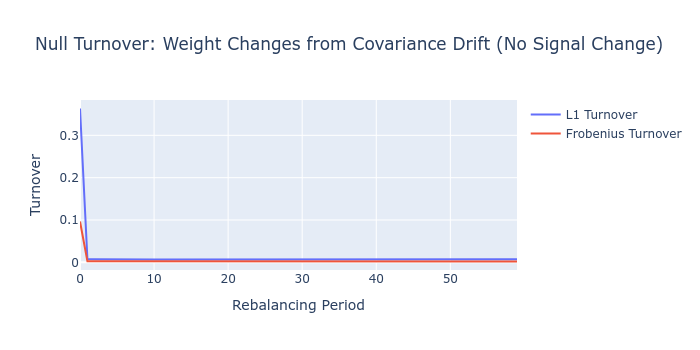

In [22]:
fig = go.Figure()
fig.add_scatter(y=turnovers_l1, mode="lines", name="L1 Turnover")
fig.add_scatter(y=turnovers_fro, mode="lines", name="Frobenius Turnover")
fig.update_layout(
    title="Null Turnover: Weight Changes from Covariance Drift (No Signal Change)",
    xaxis_title="Rebalancing Period",
    yaxis_title="Turnover",
    height=350,
)
fig.show()

**Finding**: Even with a constant signal (minimum variance), covariance drift
forces roughly one-fifth of total turnover. This *null turnover* is pure cost
drag. Strategies that ignore this diagnostic overestimate the contribution of
their signal to trading activity and understate the cost of maintaining positions.

## 10. Mechanism Summary

Each item below restates a relationship between an input dial (turnover, leverage,
expense ratio, covariance drift) and the cost-stack output. The gross return
series are real ETF returns; the turnover and leverage are configuration choices,
so the cost-drag numbers reflect those configurations applied to real returns.

1. **Trading drag scales with turnover**: at 24x annual turnover and ~8.5 bps per
   trade, the configuration loses roughly 4 percentage points of annual return to
   trading costs alone, dragging the Net Sharpe well below the Gross Sharpe.

2. **Financing matters for leverage**: a leveraged long-short configuration pays
   margin interest on the long book and borrow on the short book; at the rates
   encoded in `CostStack`, financing alone contributes ~5.5% annual drag — more
   than trading costs for moderate-turnover configurations.

3. **Fund expenses are a constant drag**: the configured ~2.2% expense ratio
   applies regardless of gross return and compounds with trading and financing.

4. **Net Sharpe ordering reflects the full cost mix, not gross alone**: the
   low-turnover SPY configuration keeps the most Sharpe (0.66 → 0.52) because it
   trades little; the high-turnover QQQ configuration sheds about half (0.54 →
   0.28) to per-trade costs; and the leveraged long-short turns negative (0.47 →
   −0.07) once margin and borrow financing stack on top of turnover. Gross
   ranking alone would not predict this order.

5. **Null turnover is a hidden cost**: even a constant-signal portfolio generates
   ~20% of total turnover from covariance drift alone in the §9 demonstration —
   cost drag that carries no informational content about the signal.

## 11. Net Sharpe by Configuration

In [23]:
# Net Sharpe summary across the three parametric configurations.
print("\nNet Sharpe by Configuration:")
viability_rows = []
for strat in strategies:
    gross_sr = compute_performance(strat["gross_returns"])["Sharpe Ratio"]
    net_sr = compute_performance(strat["net_returns"])["Sharpe Ratio"]
    if net_sr > 1.0:
        net_sr_bucket = "Net SR > 1.0"
    elif net_sr > 0.5:
        net_sr_bucket = "Net SR in (0.5, 1.0]"
    else:
        net_sr_bucket = "Net SR <= 0.5"
    viability_rows.append(
        {
            "Configuration": strat["name"],
            "Gross SR": round(gross_sr, 2),
            "Net SR": round(net_sr, 2),
            "Net SR Bucket": net_sr_bucket,
        }
    )
pl.DataFrame(viability_rows)


Net Sharpe by Configuration:


Configuration,Gross SR,Net SR,Net SR Bucket
str,f64,f64,str
"""High Turnover (24x, Long-Only)""",0.54,0.28,"""Net SR <= 0.5"""
"""Leveraged Long-Short (6x, 2x G…",0.47,-0.07,"""Net SR <= 0.5"""
"""Low Turnover (1x, Long-Only)""",0.66,0.52,"""Net SR in (0.5, 1.0]"""


**Mechanism**: the table reports Net Sharpe by configuration and bins the result
into three Net-Sharpe ranges. The bucket boundaries (1.0 and 0.5) are presentation
thresholds for grouping the demonstration outcomes, not a thumbs-up / thumbs-down
judgment on whether any of these configurations would be deployable on real data.
The point of the table is to make the gross-to-net gap visible for each
configuration of turnover and leverage.

**Next**: See [`11_cost_cliff`](11_cost_cliff.ipynb) for the intraday version of this cost arithmetic and
[`12_commission_slippage_comparison`](12_commission_slippage_comparison.ipynb) for explicit model-choice sensitivity.

## Key Takeaways

- **The cost stack is layered**: gross-to-net translation is not a single
  "cost" deduction; trading frictions, financing, and fund expenses each
  answer to different design levers. Lowering turnover does not fix a
  leverage-driven cost problem.
- **Financing dominates leveraged long-short**: under the default cost stack,
  the leveraged long-short configuration loses more Sharpe to margin and
  borrow than to trading frictions, while the high-turnover long-only loses
  most of its Sharpe to per-trade costs.
- **Turnover sensitivity is convex**: at a fixed gross signal the feasible
  turnover range shrinks sharply as one-way costs rise; the §8 surface shows
  strategies that look comfortable at 5 bps falling below Net Sharpe 0.5 at
  20-40 bps.
- **Null turnover is a hidden tax**: even a constant-signal min-variance
  portfolio incurs measurable rebalancing from covariance drift; this drag
  is paid in cost terms but carries no informational content.